# EDA – Heart Disease (Cleveland)

**CardioIA – Fase 1 | Parte 01 – Dados numéricos**

Análise exploratória do dataset Cleveland (UCI) para embasar limpeza e modelagem de **risco de doença cardíaca** (input: idade, pressão, colesterol, sintomas → output: risco).

## 1. Setup

Imports e carregamento do dataset (mesmos nomes de colunas do `load_dataset.py`).

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Caminho do CSV: 
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA_PATH = os.path.join(ROOT, "data", "heart_disease_cleveland_raw.csv")

In [3]:
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS)
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


## 2. Visão geral

Tamanho, tipos e primeiras linhas.

In [4]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (303, 14)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [5]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


**Breve conclusão:** O dataset tem **303 linhas** e **14 colunas**, sem valores NaN em nenhuma coluna. Onze colunas são numéricas em ponto flutuante (float64), uma é inteira (target, int64) e duas — **ca** e **thal** — foram lidas como texto (object), provavelmente por conterem o caractere `"?"` em algumas linhas no arquivo original. Na limpeza será preciso converter ou tratar esses valores em `ca` e `thal`.

## 3. Estatísticas descritivas

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


**Comentário:**  
- **Idade (age):** 29–77 anos (média 54,4), faixa típica para estudos cardiovasculares.  
- **Pressão em repouso (trestbps):** 94–200 mmHg; 200 é hipertensão grave mas plausível clinicamente.  
- **Colesterol (chol):** 126–564 mg/dL; a **máxima 564** chama atenção como possível outlier ou caso extremo (hipercolesterolemia severa). Mediana 241 mg/dL é razoável. Vale checar na limpeza se 564 é erro de digitação ou caso real.  
- **Frequência cardíaca máxima (thalach):** 71–202 bpm, faixa plausível.  
- **ca** e **thal** não entram no `describe()` por estarem como texto (object); serão analisadas na seção de valores faltantes.

## 4. Valores faltantes

No Cleveland original, `ca` e `thal` podem vir com `"?"`. Verificar NaN e possíveis strings.

In [7]:
print("Missing (NaN):")
print(df.isna().sum())
print("\nTipos das colunas:")
print(df.dtypes)
# Se alguma coluna for object, verificar valores únicos (ex.: "?")
for col in df.columns:
    if df[col].dtype == object:
        print(f"\n{col} - valores únicos:", df[col].unique()[:10])

Missing (NaN):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Tipos das colunas:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
target        int64
dtype: object


## 5. Variável target (diagnóstico)

0 = sem doença; 1–4 = presença/grau de doença. Para modelo de risco, costuma-se binarizar: 0 vs 1+.

In [10]:
df["target"].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [11]:
(df["target"].value_counts(normalize=True).sort_index() * 100).round(1)

target
0    54.1
1    18.2
2    11.9
3    11.6
4     4.3
Name: proportion, dtype: float64

**Conclusão:** A variável **target** tem cinco classes (0 a 4): **0** = sem doença (~54,1%), **1–4** = presença/grau de doença (~18,2%, 11,9%, 11,6%, 4,3%). Cerca de **55%** dos pacientes estão na classe 0 e **45%** nas classes 1–4 — distribuição relativamente equilibrada para modelagem. Para o objetivo “risco de doença cardíaca”, faz sentido **binarizar**: **0** = sem risco e **1** = risco (agrupando 1+2+3+4), alinhado ao uso comum do dataset Cleveland na literatura. Na limpeza, criar uma coluna `target_binario` (0/1) para uso no modelo.

## 6. Variáveis numéricas principais

Idade, pressão em repouso, colesterol e frequência cardíaca máxima (thalach).

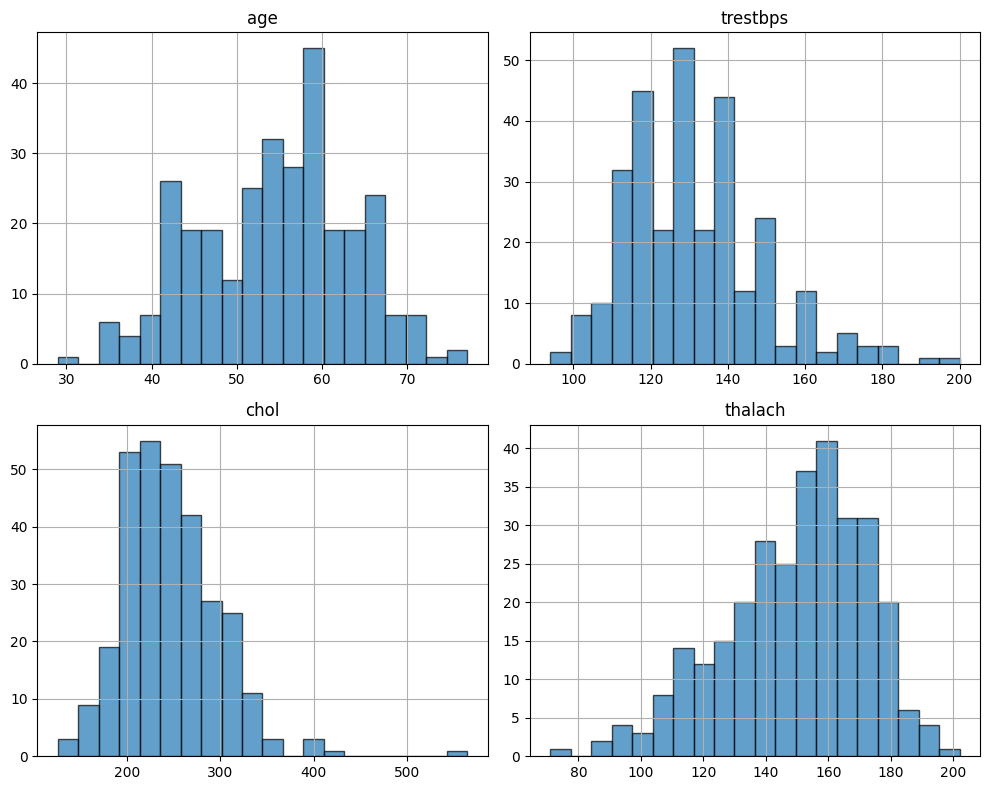

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ["age", "trestbps", "chol", "thalach"]):
    df[col].hist(ax=ax, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Conclusão:** Os histogramas mostram distribuições plausíveis para uma coorte cardiológica, com formas que vale registrar para a modelagem. **age** tem formato aproximadamente simétrico com possível bimodalidade: pico principal em 55–60 anos e outro em torno de 42–44 anos; a maior parte dos indivíduos está entre 40 e 70 anos, com poucos abaixo de 35 ou acima de 70. **trestbps** (pressão em repouso) tem **assimetria à direita**: concentração em 120–140 mmHg (picos em 120–130 e 135–140), com poucas observações acima de 160 e algumas até 200. **chol** (colesterol) apresenta **forte assimetria à direita**: pico nítido em 200–220 mg/dL, maioria entre 180 e 300 mg/dL e cauda longa à direita, com poucos valores acima de 400 e **um valor extremo em torno de 500–560** (o 564 do describe), claramente visível como outlier no histograma. **thalach** (frequência cardíaca máxima) sugere **assimetria à esquerda** ou bimodalidade, com pico principal em 155–160 bpm e outra concentração em 140–145 bpm; a maior parte está entre 120 e 180 bpm. As assimetrias de **trestbps** e **chol** podem motivar, na etapa de modelagem, transformação ou tratamento explícito de outliers (ex.: o colesterol 564), dependendo do algoritmo usado. Nenhuma variável indica erro grosseiro de digitação além desse ponto extremo de colesterol.

## 7. Relação com o target

Médias das variáveis numéricas por valor de target.

In [13]:
num_cols = ["age", "trestbps", "chol", "thalach"]
df.groupby("target")[num_cols].mean()

,age,trestbps,chol,thalach
target,,,,
0,52.585366,129.250000,242.640244,158.378049
1,55.381818,133.254545,249.109091,145.927273
2,58.027778,134.194444,259.277778,135.583333
3,56.000000,135.457143,246.457143,132.057143
4,59.692308,138.769231,253.384615,140.615385


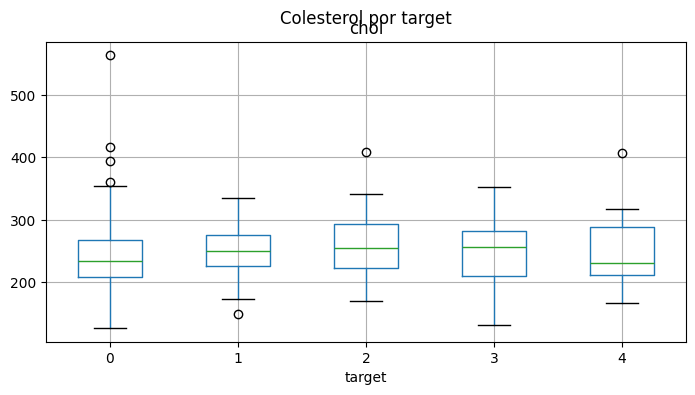

In [14]:
df.boxplot(column="chol", by="target", figsize=(8, 4))
plt.suptitle("Colesterol por target")
plt.show()

**Conclusão:** O box plot de colesterol por target mostra que as **medianas e a dispersão (IQR) são muito parecidas** entre as classes 0–4: todas ficam em torno de 230–250 mg/dL, com caixas sobrepostas. Ou seja, o colesterol **sozinho** não separa bem “sem doença” vs “com doença” — há muita sobreposição. O que chama atenção é o **target 0** (sem doença), que concentra **vários outliers altos** de colesterol, incluindo o valor extremo **acima de 500** (o 564 do dataset). Isso pode indicar que pessoas sem doença no exame mesmo com colesterol muito alto existem na amostra (ou efeito de medicação/outros fatores), e que o modelo não pode depender só de colesterol para prever risco. Já a **tabela de médias** (groupby) por target mostra tendências mais claras em outras variáveis: **idade** e **pressão** tendem a subir com o target (ex.: média de idade de 52,6 em target 0 para 59,7 em target 4), e **thalach** (frequência cardíaca máxima) **diminui** quando o target aumenta (158 bpm em target 0 vs 132–141 bpm nos target 1–4) — o que faz sentido clinicamente (ex.: uso de betabloqueadores ou menor capacidade de esforço). Para o modelo de risco cardíaco, **thalach**, **idade** e **trestbps** podem ser mais informativos que o colesterol isolado; o colesterol ainda pode ajudar em combinação com outras variáveis ou após tratar o outlier 564.

## 8. Conclusões e próximos passos

### Resumo da qualidade

- **Tamanho:** 303 linhas × 14 colunas; atende ao mínimo de 100 linhas para a Parte 01.
- **Tipos:** 11 colunas float64, 1 int64 (target), 2 object (**ca**, **thal**) — estas foram lidas como texto, provavelmente por conterem `"?"` no CSV (a célula de valores faltantes não mostrou NaN porque `"?"` não é NaN; na limpeza será preciso tratar).
- **Missings:** Nenhum NaN explícito; os possíveis `"?"` em **ca** e **thal** serão tratados na limpeza (substituir por NaN e **preencher com a moda**).
- **Outlier:** Colesterol **564** (target 0) identificado como valor extremo; **decisão:** manter como caso real e documentar no README.
- **Distribuições:** Assimetrias em trestbps e chol (à direita) e em thalach (à esquerda); na modelagem futura pode ser útil transformação ou algoritmos pouco sensíveis à normalidade.

### Decisões para a limpeza (fechadas)

1. **ca e thal:** Substituir `"?"` por NaN, converter para numérico e **preencher com a moda** de cada coluna (mantém as 303 linhas; decisão alinhada à prática quando há poucos missings).
2. **Target:** Criar coluna **target_binario**: 0 quando `target == 0`, 1 quando `target >= 1`, para uso no modelo de “risco de doença cardíaca”.
3. **Colesterol 564:** **Manter** como está, tratando como caso extremo real (hipercolesterolemia severa). Documentar no README que o valor foi mantido de forma consciente após a EDA.
4. **Tipos:** Garantir que todas as colunas numéricas tenham tipo numérico após tratar ca/thal.

### Próximo passo

Implementar um **script de limpeza** (ex.: `scripts/clean_heart_data.py`) que:
- Carrega `data/heart_disease_cleveland_raw.csv` com os mesmos nomes de colunas;
- Trata `"?"` em **ca** e **thal** (substituir por NaN e preencher com moda); converte **ca** e **thal** para numérico;
- Cria **target_binario**;
- Mantém o colesterol 564 (documentar no README);
- Salva o resultado em `data/heart_real_cleaned.csv`.

Assim a base limpa fica reprodutível e pronta para o passo seguinte (híbrido com dados simulados ou uso direto no modelo).